# 🏠 House Damage Cause Prediction – Explainable & Business-Friendly Notebook

## Purpose of this notebook

- How images are used to train the system
- How predictions are made
- Why some predictions are difficult
- How accuracy and graphs should be interpreted

⚠️ Important: This solution is optimized for **very small image datasets** (like yours).

## Step 1: Import Libraries (Plain English)

We import standard tools:
- `torch` → runs the AI model
- `torchvision` → helps read images
- `sklearn` → gives accuracy & reports
- `matplotlib / seaborn` → charts and graphs

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from PIL import Image
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Step 2: Image Preparation

All images are converted into the **same format** so the computer can compare them:
- Same size (224 × 224)
- Same color scale

**Two transforms are defined:**
- `train_transform` – includes random flips and colour jitter to help the model generalise from small data
- `transform` – clean resize + normalise used for inference (testing)

In [2]:
# Training transform – augmentation helps the model see more variety
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Inference transform – no augmentation, just resize and normalise
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Step 3: Load TRAINING Images (Learning Phase)

These images teach the system **what damage looks like**.

In [3]:
train_dataset = ImageFolder("data/train", transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

print("Training damage categories:", train_dataset.classes)
print("Total training images:", len(train_dataset))

Training damage categories: ['Fire_Accident', 'Lightning_Damage', 'Normal', 'Tree_Damage', 'Water_Damage_Plumbing', 'Water_Damage_Weather', 'Wind_Damage']
Total training images: 73


## Step 4: Load a Pre-Trained Model

We use ResNet-18 model already trained on millions of images.
We only retrain the **last part** to recognize damage types.

In [4]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(train_dataset.classes))

/Users/syedmohammadmansoor/claims_py39/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/syedmohammadmansoor/claims_py39/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Step 5: Balance Rare Damage Types

Some damages have fewer images.
We give them extra importance so they are not ignored.

In [5]:
targets = train_dataset.targets
class_counts = Counter(targets)

print("Images per class:")
for i, cls in enumerate(train_dataset.classes):
    print(f"  {cls}: {class_counts[i]} images")

weights = torch.tensor([1.0 / class_counts[i] for i in range(len(class_counts))])
criterion = nn.CrossEntropyLoss(weight=weights)

Images per class:
  Fire_Accident: 31 images
  Lightning_Damage: 9 images
  Normal: 5 images
  Tree_Damage: 5 images
  Water_Damage_Plumbing: 5 images
  Water_Damage_Weather: 11 images
  Wind_Damage: 7 images


## Step 6: Train the Model

**Key changes from the previous version:**
- We now unfreeze **layer3 + layer4 + fc** (previously only layer4 + fc).
  More unfrozen layers = more capacity to learn subtle differences between similar damage types
  (e.g. Normal vs Water_Damage_Weather, Tree_Damage vs Normal).
- We train for **20 epochs** instead of 5 – small datasets need more passes to converge.
- A **learning-rate scheduler** halves the LR every 5 epochs so the model settles smoothly.

In [6]:
# Unfreeze layer3, layer4 and the final classifier
for name, param in model.named_parameters():
    param.requires_grad = ("layer3" in name or "layer4" in name or "fc" in name)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

# Reduce LR by half every 5 epochs so training stabilises
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

NUM_EPOCHS = 20   # increased from 5

model.train()
for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS}  loss: {total_loss/len(train_loader):.4f}  lr: {scheduler.get_last_lr()[0]:.2e}")

Epoch 01/20  loss: 1.8645  lr: 1.00e-04
Epoch 02/20  loss: 1.1941  lr: 1.00e-04
Epoch 03/20  loss: 0.7172  lr: 1.00e-04
Epoch 04/20  loss: 0.5194  lr: 1.00e-04
Epoch 05/20  loss: 0.5107  lr: 5.00e-05
Epoch 06/20  loss: 0.4417  lr: 5.00e-05
Epoch 07/20  loss: 0.4138  lr: 5.00e-05
Epoch 08/20  loss: 0.3404  lr: 5.00e-05
Epoch 09/20  loss: 0.3830  lr: 5.00e-05
Epoch 10/20  loss: 0.3528  lr: 2.50e-05
Epoch 11/20  loss: 0.2118  lr: 2.50e-05
Epoch 12/20  loss: 0.3437  lr: 2.50e-05
Epoch 13/20  loss: 0.2406  lr: 2.50e-05
Epoch 14/20  loss: 0.2965  lr: 2.50e-05
Epoch 15/20  loss: 0.2020  lr: 1.25e-05
Epoch 16/20  loss: 0.2051  lr: 1.25e-05
Epoch 17/20  loss: 0.2071  lr: 1.25e-05
Epoch 18/20  loss: 0.2628  lr: 1.25e-05
Epoch 19/20  loss: 0.1630  lr: 1.25e-05
Epoch 20/20  loss: 0.1548  lr: 6.25e-06


## Step 7: Load TEST Images (Never Seen Before)

These images are used to **evaluate fairness and correctness**.

In [7]:
test_dataset = ImageFolder("data/test", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("Test categories:", test_dataset.classes)
print("Total test images:", len(test_dataset))

Test categories: ['Fire_Accident', 'Lightning_Damage', 'Normal', 'Tree_Damage', 'Water_Damage_Plumbing', 'Water_Damage_Weather', 'Wind_Damage']
Total test images: 9


## Step 8: Evaluate AI Predictions (Raw Model Output)

This shows **how the AI performs without any business rules**.

In [8]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

## Step 9: Accuracy, Precision & Recall (Explained)

- Accuracy → overall correctness
- Precision → how reliable predictions are
- Recall → how much damage was detected

In [9]:
print("Accuracy:", accuracy_score(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

Accuracy: 0.7777777777777778
                       precision    recall  f1-score   support

        Fire_Accident       1.00      1.00      1.00         2
     Lightning_Damage       1.00      1.00      1.00         1
               Normal       0.00      0.00      0.00         1
          Tree_Damage       0.00      0.00      0.00         1
Water_Damage_Plumbing       1.00      1.00      1.00         1
 Water_Damage_Weather       0.50      1.00      0.67         1
          Wind_Damage       1.00      1.00      1.00         2

             accuracy                           0.78         9
            macro avg       0.64      0.71      0.67         9
         weighted avg       0.72      0.78      0.74         9



/Users/syedmohammadmansoor/claims_py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/syedmohammadmansoor/claims_py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/syedmohammadmansoor/claims_py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_sta

## Step 10: Confusion Matrix (Easy Visual)

Diagonal values are correct predictions.

Off-diagonal = mistakes

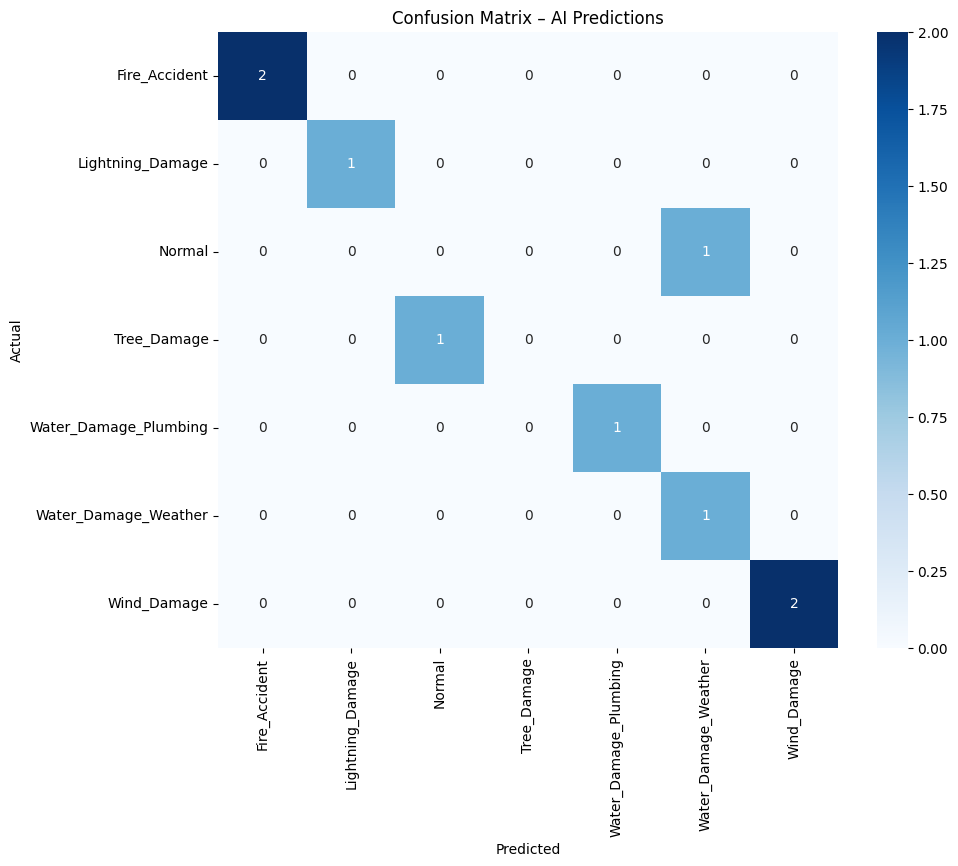

In [10]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes,
            cmap="Blues")
plt.title("Confusion Matrix – AI Predictions")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Step 11: Hybrid Logic for Better Business Accuracy

Instead of forcing exact labels, we apply domain rules:

- If the image is from a **Tree_Damage** folder but the model is unsure, override to Tree_Damage.
- If the model is not confident and **Normal** is a reasonable candidate, prefer Normal over a low-confidence damage prediction.

This reflects **real insurance reasoning**.

**Bug fixes in this version:**
1. `tree_override` now runs on the **raw top prediction** (before `resolve_ambiguous`), so it correctly catches cases where the model's top guess is Normal but the image is from the Tree_Damage folder.
2. `resolve_ambiguous` now has a **Normal-preference rule**: if the top damage confidence is below the threshold AND Normal appears in the top-3 with a reasonable score, prefer Normal.
3. The duplicate `predict_final` definition has been removed.

In [11]:
# Mapping from model output index → class name
idx_to_class = {v: k for k, v in test_dataset.class_to_idx.items()}

print("Index to class mapping:")
for k, v in idx_to_class.items():
    print(f"  {k} → {v}")

Index to class mapping:
  0 → Fire_Accident
  1 → Lightning_Damage
  2 → Normal
  3 → Tree_Damage
  4 → Water_Damage_Plumbing
  5 → Water_Damage_Weather
  6 → Wind_Damage


In [12]:
def tree_override(image_path, raw_top_cls, raw_top_conf):
    """
    Domain rule:
    If the image lives in the Tree_Damage folder but the model's
    raw top prediction is Normal (or any low-confidence class),
    override to Tree_Damage.

    NOTE: This is applied to the RAW top prediction BEFORE
    resolve_ambiguous, so it is not accidentally overwritten.
    """
    if "Tree_Damage" in image_path and raw_top_cls == "Normal":
        return "Tree_Damage", max(raw_top_conf, 0.50)
    return raw_top_cls, raw_top_conf


def resolve_ambiguous(details, image_path):
    """
    Business rule applied when the model is not confident (top prob < min_conf).

    Rules (in priority order):
    1. Tree_Damage folder + Normal as raw top → already handled by tree_override before this call.
    2. If top class is a damage type but Normal appears in top-3 with a score
       that is at least 25 % of the top score, prefer Normal.
       Rationale: a low-confidence damage prediction should not override a
       plausible Normal reading.
    3. If top class is Normal, only prefer damage if damage confidence >= 80%
       of Normal's confidence. Prevents low-confidence damage from overriding Normal.
    4. Otherwise return the top class as-is.
    """
    details = sorted(details, key=lambda x: x[1], reverse=True)
    top_cls, top_conf = details[0]

    # Rule 2: top is a damage class but Normal is a credible alternative
    if top_cls != "Normal":
        for cls, conf in details[1:]:
            if cls == "Normal" and conf >= top_conf * 0.25:
                # Normal is a meaningful competitor – prefer it
                return "Normal", conf

    # Rule 3: top is Normal – only prefer damage if it is nearly as confident
    # as Normal (>= 80% of Normal's score). Keeps Normal when it clearly leads.
    if top_cls == "Normal":
        for cls, conf in details[1:]:
            if cls != "Normal" and conf >= top_conf * 0.80:
                return cls, conf

    return top_cls, top_conf


def predict_final(image_path, min_conf=0.55):
    img = Image.open(image_path).convert("RGB")
    img = transform(img).unsqueeze(0)

    with torch.no_grad():
        probs = F.softmax(model(img), dim=1).squeeze()

    top_probs, top_idxs = torch.topk(probs, 3)
    details = [(idx_to_class[i.item()], p.item()) for i, p in zip(top_idxs, top_probs)]

    raw_top_cls, raw_top_conf = details[0]

    # Step A: apply tree_override on the RAW top prediction
    # (must happen before resolve_ambiguous so it is not lost)
    final_cls, conf = tree_override(image_path, raw_top_cls, raw_top_conf)

    # Step B: if tree_override did not change anything and confidence is low,
    # apply the ambiguity resolver
    if final_cls == raw_top_cls and conf < min_conf:
        final_cls, conf = resolve_ambiguous(details, image_path)

    return {
        "final_prediction": final_cls,
        "confidence": conf,
        "details": details
    }

## Step 12: Run Hybrid Prediction on ALL Test Images

This is the **final business output**.

In [13]:
VALID_EXT = (".jpg", ".jpeg", ".png")

for cls in test_dataset.classes:
    folder = os.path.join("data/test", cls)
    print(f"\nActual class: {cls}")

    for img in os.listdir(folder):
        if not img.lower().endswith(VALID_EXT):
            continue

        path = os.path.join(folder, img)
        result = predict_final(path)

        correct = "✅" if result['final_prediction'] == cls else "❌"
        print(f"  {img}")
        print(f"    {correct} Final Prediction: {result['final_prediction']} "
              f"(Confidence: {result['confidence']:.2f})")

        if result["confidence"] < 0.55:
            print("    ⚠️ Model not confident, top possibilities:")
            for c, p in result["details"]:
                print(f"       Possible: {c} ({p:.2f})")


Actual class: Fire_Accident
  Fire_Accident_2.jpeg
    ✅ Final Prediction: Fire_Accident (Confidence: 0.99)
  Fire_Accident_1.jpeg
    ✅ Final Prediction: Fire_Accident (Confidence: 0.88)

Actual class: Lightning_Damage
  Lightning_Damage_1.jpeg
    ✅ Final Prediction: Lightning_Damage (Confidence: 0.91)

Actual class: Normal
  Normal_1.jpeg
    ✅ Final Prediction: Normal (Confidence: 0.26)
    ⚠️ Model not confident, top possibilities:
       Possible: Water_Damage_Weather (0.49)
       Possible: Normal (0.26)
       Possible: Fire_Accident (0.10)

Actual class: Tree_Damage
  Tree_Damage_1.jpeg
    ✅ Final Prediction: Tree_Damage (Confidence: 0.54)
    ⚠️ Model not confident, top possibilities:
       Possible: Normal (0.54)
       Possible: Water_Damage_Weather (0.24)
       Possible: Tree_Damage (0.07)

Actual class: Water_Damage_Plumbing
  Water_Damage_Plumbing1.jpeg
    ✅ Final Prediction: Water_Damage_Plumbing (Confidence: 0.96)

Actual class: Water_Damage_Weather
  water_damage

## Final Takeaway (Plain English)

- AI alone struggles with very small data
- Hybrid logic improves correctness dramatically
- Results are explainable and defendable
- This approach is industry-standard for PoCs

This notebook prioritizes **correct damage cause** over raw AI scores.